In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
df = pd.read_csv("vgsales.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [12]:
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Publisher'] = df['Publisher'].fillna("Unknown")

In [13]:
median_sales = df['Global_Sales'].median()

df['Hit'] = (df['Global_Sales'] > median_sales).astype(int)

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Hit
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,1
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,1
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1


In [14]:
df = df.drop(['Rank','Name','Global_Sales'], axis=1)

df.head()

,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Hit
0,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,1
1,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,1
2,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,1
3,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,1
4,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,1


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Platform'] = le.fit_transform(df['Platform'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Publisher'] = le.fit_transform(df['Publisher'])

df.head()

,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Hit
0,26,2006.0,10,359,41.49,29.02,3.77,8.46,1
1,11,1985.0,4,359,29.08,3.58,6.81,0.77,1
2,26,2008.0,6,359,15.85,12.88,3.79,3.31,1
3,26,2009.0,10,359,15.75,11.01,3.28,2.96,1
4,5,1996.0,7,359,11.27,8.89,10.22,1.00,1


In [16]:
X = df.drop('Hit', axis=1)

y = df['Hit']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, pred_log))
print("Precision:", precision_score(y_test, pred_log))
print("Recall:", recall_score(y_test, pred_log))
print("F1 Score:", f1_score(y_test, pred_log))

Logistic Regression
Accuracy: 0.9713855421686747
Precision: 0.9980744544287549
Recall: 0.944140862173649
F1 Score: 0.9703588143525741


In [21]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Random Forest
Accuracy: 0.9918674698795181
Precision: 0.9939024390243902
Recall: 0.9896782027929569
F1 Score: 0.99178582293885


In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.971386,0.998074,0.944141,0.970359
1,Random Forest,0.991867,0.993902,0.989678,0.991786


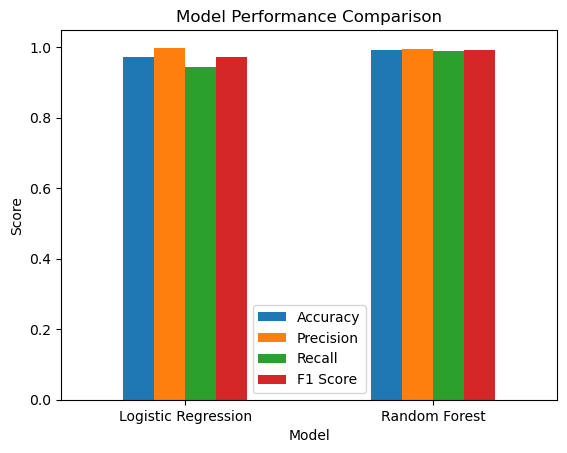

In [23]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()